# Survival analysis (time-to-serious delinquency)

This notebook covers survival time and censoring from **`installments_payments`**, **Kaplan–Meier** curves (overall and by **XGBoost risk quartile**), a **multivariate log-rank** test, and a **Cox proportional hazards** model on a small set of strong credit covariates (aligned with the SHAP story in `04_explainability.ipynb`).

**Endpoint (proxy)** — Rows are scheduled instalments on **previous Home Credit contracts**. We define a **serious delinquency** event as the first instalment with **≥ 60 days** between scheduled due date and actual payment (`DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`). **Time** is measured in **instalment periods** from the first observed instalment on the chosen contract to that event (or to the last instalment if censored). One **representative previous loan** per applicant is used: the `SK_ID_PREV` with the **most instalment rows** (richest payment history).

**Prerequisites** — `data/home_credit.db` loaded from Kaggle CSVs (see README). **`uv run python -m src.train`** so `model/model_uncalibrated.pkl` exists for risk stratification.

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

warnings.filterwarnings("ignore", category=UserWarning)


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").is_file() and (p / "src" / "metrics.py").is_file():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml + src/).")


ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT))

from src.features import build_feature_matrix  # noqa: E402

RANDOM_STATE = 42
DB_PATH = ROOT / "data" / "home_credit.db"
LATE_DPD_THRESHOLD = 60  # days after scheduled due (proxy for serious stress)

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DB_PATH}. Run sql/load.sql against your data/ CSVs per README."
    )

## 1. Survival labels from `installments_payments`

We restrict to applicants in **`application_train`** and compute duration / event on the representative previous loan described above.

In [2]:
SURVIVAL_SQL = f"""
WITH inst AS (
    SELECT
        ip.SK_ID_CURR,
        ip.SK_ID_PREV,
        ip.NUM_INSTALMENT_NUMBER,
        ip.DAYS_ENTRY_PAYMENT - ip.DAYS_INSTALMENT AS late_days
    FROM installments_payments ip
    INNER JOIN application_train tr ON ip.SK_ID_CURR = tr.SK_ID_CURR
    WHERE ip.DAYS_ENTRY_PAYMENT IS NOT NULL
      AND ip.DAYS_INSTALMENT IS NOT NULL
),
loan_stats AS (
    SELECT
        SK_ID_CURR,
        SK_ID_PREV,
        MIN(NUM_INSTALMENT_NUMBER) AS num_min,
        MAX(NUM_INSTALMENT_NUMBER) AS num_max,
        COUNT(*) AS n_inst,
        MIN(CASE WHEN late_days >= {LATE_DPD_THRESHOLD} THEN NUM_INSTALMENT_NUMBER END) AS num_at_event
    FROM inst
    GROUP BY SK_ID_CURR, SK_ID_PREV
),
picked AS (
    SELECT * EXCLUDE (rn)
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (PARTITION BY SK_ID_CURR ORDER BY n_inst DESC) AS rn
        FROM loan_stats
    ) s
    WHERE rn = 1
)
SELECT
    p.SK_ID_CURR,
    CASE WHEN p.num_at_event IS NOT NULL THEN 1 ELSE 0 END AS event,
    CASE
        WHEN p.num_at_event IS NOT NULL THEN (p.num_at_event - p.num_min + 1)::INTEGER
        ELSE (p.num_max - p.num_min + 1)::INTEGER
    END AS duration,
    p.n_inst
FROM picked p
"""

conn = duckdb.connect(str(DB_PATH))
surv = conn.execute(SURVIVAL_SQL).df()
conn.close()

surv["duration"] = surv["duration"].clip(lower=1)
print(surv.shape)
print("event rate:", surv["event"].mean().round(3))
surv.head()

(291635, 4)
event rate: 0.017


,SK_ID_CURR,event,duration,n_inst
0,189449,0,10,11
1,174883,0,50,50
2,159473,0,13,13
3,112492,0,20,20
4,185887,0,23,25


## 2. Kaplan–Meier — overall

The KM estimator respects **right censoring**: many borrowers never hit the 60-day-late threshold within the observed instalment window.

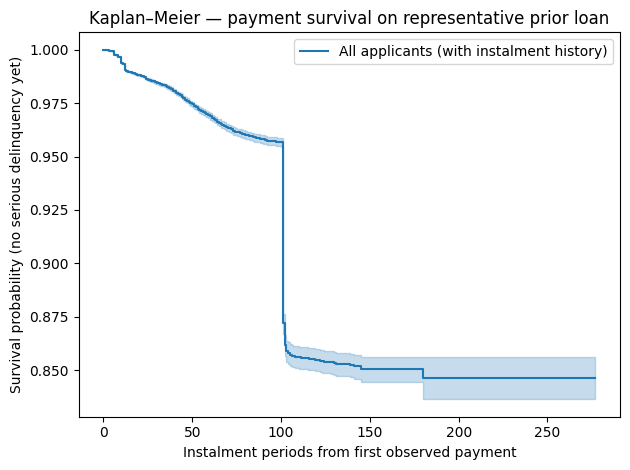

inf


In [3]:
kmf_all = KaplanMeierFitter(label="All applicants (with instalment history)")
kmf_all.fit(surv["duration"], surv["event"])

ax = kmf_all.plot_survival_function()
plt.xlabel("Instalment periods from first observed payment")
plt.ylabel("Survival probability (no serious delinquency yet)")
plt.title("Kaplan–Meier — payment survival on representative prior loan")
plt.tight_layout()
plt.show()

print(kmf_all.median_survival_time_)

## 3. Stratify by XGBoost risk quartile

We reuse the **same cached feature matrix** as `04_explainability.ipynb`, load **`model_uncalibrated.pkl`**, and assign each applicant a **risk score** (raw XGBoost probability of `TARGET=1`). **Quartiles** of that score define four groups for overlaid KM curves and a **log-rank** test of equality across curves.

In [4]:
uncal_path = ROOT / "model" / "model_uncalibrated.pkl"
if not uncal_path.exists():
    raise FileNotFoundError(
        "Missing model/model_uncalibrated.pkl — from repo root run: uv run python -m src.train"
    )
pipeline = joblib.load(uncal_path)

conn = duckdb.connect(str(DB_PATH))
df = build_feature_matrix(conn)
conn.close()

X = df.drop(columns=["TARGET", "SK_ID_CURR"])
ids = df["SK_ID_CURR"]

risk = pd.Series(pipeline.predict_proba(X)[:, 1], index=X.index, name="risk_score")
risk_quartile = pd.qcut(risk, 4, labels=["Q1 (lowest risk)", "Q2", "Q3", "Q4 (highest risk)"])
scored = pd.DataFrame({"SK_ID_CURR": ids, "risk_score": risk.values, "risk_quartile": risk_quartile.astype(str)})

merged = surv.merge(scored, on="SK_ID_CURR", how="inner")
print("rows with both survival labels and model score:", len(merged))
merged.groupby("risk_quartile", observed=False)["event"].agg(["mean", "count"])

rows with both survival labels and model score: 291635


,mean,count
risk_quartile,,
Q1 (lowest risk),0.013225,71530
Q2,0.016024,72454
Q3,0.017263,73220
Q4 (highest risk),0.022410,74431


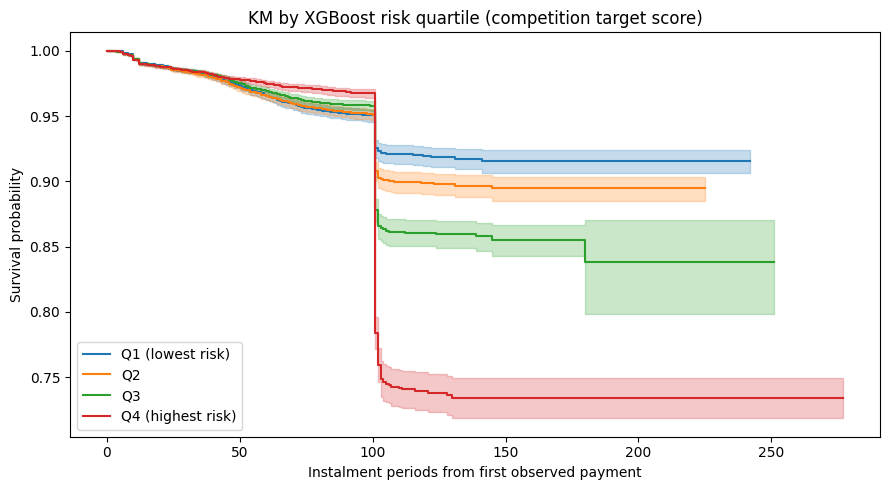

In [5]:
plt.figure(figsize=(9, 5))
for label in ["Q1 (lowest risk)", "Q2", "Q3", "Q4 (highest risk)"]:
    sub = merged.loc[merged["risk_quartile"] == label]
    kmf = KaplanMeierFitter(label=label)
    kmf.fit(sub["duration"], sub["event"])
    kmf.plot_survival_function(ax=plt.gca())

plt.xlabel("Instalment periods from first observed payment")
plt.ylabel("Survival probability")
plt.title("KM by XGBoost risk quartile (competition target score)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [6]:
lr = multivariate_logrank_test(
    merged["duration"],
    merged["risk_quartile"],
    merged["event"],
)
print(lr.summary)
print("p-value:", float(lr.p_value))

   test_statistic             p    -log2(p)
0      194.737705  5.782599e-42  136.989262
p-value: 5.782598589443564e-42


## 4. Cox proportional hazards

We fit **`CoxPHFitter`** on covariates that typically dominate SHAP in this project: **external scores**, **age**, **payment behaviour** (`inst_*`), and **bureau leverage**. Hazard ratios **> 1** mean higher hazard of reaching the serious delinquency event earlier, **holding other covariates fixed**.

Because **`check_assumptions`** must run on the **same rows** used to fit the Cox model, and the full matrix is large (~hundreds of thousands of rows), we fit Cox on a **random subsample** (up to 30k complete rows) so the Schoenfeld-style diagnostic completes in reasonable time. **Kaplan–Meier and log-rank** above still use everyone with instalment history and a model score.

In [7]:
cox_cols = [
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DAYS_BIRTH",
    "inst_pct_late_last365",
    "inst_overall_payment_to_instalment",
    "bureau_debt_to_credit_ratio",
    "AMT_ANNUITY",
    "AMT_INCOME_TOTAL",
]

cox_base = df[["SK_ID_CURR"] + cox_cols].merge(
    surv[["SK_ID_CURR", "duration", "event"]], on="SK_ID_CURR", how="inner"
)

cox_df = cox_base.replace([np.inf, -np.inf], np.nan).dropna(subset=cox_cols + ["duration", "event"])
cox_full = cox_df.drop(columns=["SK_ID_CURR"])
_cox_fit_n = min(30_000, len(cox_full))
cox_fit = cox_full.sample(n=_cox_fit_n, random_state=RANDOM_STATE)
print("Cox fit rows (subsample of complete cases):", len(cox_fit), "| all complete:", len(cox_full))

cph = CoxPHFitter()
cph.fit(cox_fit, duration_col="duration", event_col="event")
cph.print_summary()

Cox fit rows (subsample of complete cases): 30000 | all complete: 168561


<lifelines.CoxPHFitter: fitted with 30000 total observations, 29523 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 30000
number of events observed = 477
   partial log-likelihood = -4017.97
         time fit was run = 2026-04-22 18:25:57 UTC

---
                                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                           
EXT_SOURCE_2                       -0.40      0.67      0.24           -0.87            0.07                0.42                1.08
EXT_SOURCE_3                       -0.40      0.67      0.25           -0.89            0.09                0.41                1.09
DAYS_BIRTH                         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
inst_pct_late_last365               0.39      1.48      0.32           -0.23            1.02                0.79                2.78
inst_overall_payment_to_instalment -4.65      0.01      0.44           -5.52           -3.78                0.00                0.02
bureau_debt_to_credit_ratio        -0.45      0.64      0.18           -0.79           -0.10                0.45                0.90
AMT_ANNUITY                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
AMT_INCOME_TOTAL                   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                                    cmp to      z      p  -log2(p)
covariate                                                         
EXT_SOURCE_2                          0.00  -1.65   0.10      3.34
EXT_SOURCE_3                          0.00  -1.61   0.11      3.23
DAYS_BIRTH                            0.00  -0.54   0.59      0.76
inst_pct_late_last365                 0.00   1.23   0.22      2.19
inst_overall_payment_to_instalment    0.00 -10.48 <0.005     82.88
bureau_debt_to_credit_ratio           0.00  -2.55   0.01      6.53
AMT_ANNUITY                           0.00   0.07   0.94      0.08
AMT_INCOME_TOTAL                      0.00  -3.49 <0.005     10.99
---
Concordance = 0.65
Partial AIC = 8051.93
log-likelihood ratio test = 239.41 on 8 df
-log2(p) of ll-ratio test = 154.53

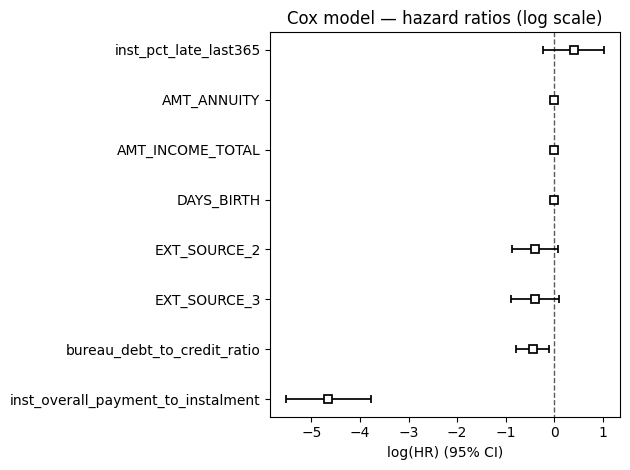

In [8]:
cph.plot()
plt.title("Cox model — hazard ratios (log scale)")
plt.tight_layout()
plt.show()

In [9]:
cph.check_assumptions(cox_fit, show_plots=False, p_value_threshold=0.01)

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'EXT_SOURCE_2' failed the non-proportional test: p-value is 0.0011.

   Advice 1: the functional form of the variable 'EXT_SOURCE_2' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'EXT_SOURCE_2' using pd.cut, and then specify it in
`strata=['EXT_SOURCE_2', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'EXT_SOURCE_3' failed the non-proportional test: p-value is 0.0018.

   Advice 1: the functional form of the variable 'EXT_SOURCE_3' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how

[]

## 5. Binary classification vs survival framing

| Lens | Question | Typical use |
|------|----------|-------------|
| **Binary (`TARGET`)** | Will this applicant go into payment difficulties on the **current** application (single horizon)? | **Origination decision**: approve / decline, cut-off policy, static PD at a fixed horizon. |
| **Survival (here)** | **When** does serious stress appear along an **observed instalment path** on prior contracts, accounting for **censoring**? | **Collections and provisioning**: time-to-problem, cash-flow timing, stress accumulation; complements a point-in-time score. |

The XGBoost model is trained on **tabular aggregates** (including instalment summaries); this notebook makes the **time axis** explicit. A **high risk score** should correlate with **faster** payment stress on the survival curve if the score captures dynamic behaviour — the KM split and Cox covariates are ways to **see** that alignment.
